# 3. Train Masking Model and Count Decoder

Fine-tune PerturbGen on the LPS tokenized data from notebook 02.

**Requirements**
- CUDA GPU (this step will not train on CPU)
- Poetry / `.venv` kernel with `perturbgen` installed
- `geneformer` installed (`pip install git+https://huggingface.co/ctheodoris/Geneformer@0960cf63969aa0dfdb00c6fd46316a3fbe7a1c9b`)
- Enough disk for checkpoints (several GB)

## 3.0. Shared paths and environment

`perturbgen` changes the working directory to the workspace root (`/home/stuke1/perturbgen`), where `T_perturb/` lives. Paths below match that layout.

This notebook is configured for **4 GPUs**: `CUDA_VISIBLE_DEVICES=0,1,2,7`.

**Frozen split (from notebook 02 §2.6):** train / val / test indices are loaded from
`TOKENIZED/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl` via `--split_path`.
Do not re-tokenizeize without re-freezing that split if you want analyses to stay comparable.

In [2]:
import datetime as dt
import os
import subprocess
from pathlib import Path

# Workspace root (== perturbgen.configs.paths.ROOT)
WORKSPACE = Path("/home/stuke1/perturbgen")
REPO = WORKSPACE / "Perturbgen"
TOKENIZED = WORKSPACE / "T_perturb" / "tokenized_data" / "LPS_all_tps_2k"
LOG_ROOT = Path("/mnt/sod2-project/csb4/stuke1/perturbgen/logs")
LOG_ROOT.mkdir(parents=True, exist_ok=True)

# Tokenized LPS outputs from notebook 02
SRC_DATASET = str(TOKENIZED / "dataset_2000_hvg_src" / "normal.dataset")
TGT_DATASET_FOLDER = str(TOKENIZED / "dataset_2000_hvg_tgt")
SRC_ADATA = str(TOKENIZED / "h5ad_pairing_2000_hvg_src" / "normal.h5ad")
TGT_ADATA_FOLDER = str(TOKENIZED / "h5ad_pairing_2000_hvg_tgt")
MAPPING_DICT_PATH = str(TOKENIZED / "token_id_to_genename_2000_hvg.pkl")

# Frozen train/val/test indices from notebook 02 §2.6
SPLIT_PATH = str(
    TOKENIZED
    / "splits"
    / "stratified_cell_type_harmonized_seed42_80_10_10.pkl"
)

# Pretrained encoder shipped with the repo
ENCODER_PATH = str(
    REPO
    / "pretraining_cohort"
    / "20250709_1223_cellgen_train_masking_lr_5e-05_wd_1e-06_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_42-epoch=00.ckpt"
)

VAR_LIST = ["cell_type_harmonized", "time_after_LPS"]
PRED_TPS = ["1", "2", "3"]  # 1=90m, 2=6h, 3=10h

# Requested GPUs
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,7"
os.environ.setdefault("WANDB_MODE", "offline")
os.environ["PYTHONUNBUFFERED"] = "1"

required = [
    SRC_DATASET,
    TGT_DATASET_FOLDER,
    SRC_ADATA,
    TGT_ADATA_FOLDER,
    MAPPING_DICT_PATH,
    ENCODER_PATH,
    SPLIT_PATH,
]
missing = [p for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Missing paths (run notebook 02 §2.6 if SPLIT_PATH is missing):\n"
        + "\n".join(missing)
    )

import pickle

with open(SPLIT_PATH, "rb") as _f:
    _split = pickle.load(_f)
print(
    "Frozen split:",
    SPLIT_PATH,
    f"(train={len(_split['train_indices'])}, "
    f"val={len(_split['val_indices'])}, "
    f"test={len(_split['test_indices'])})",
)


def run_and_stream(cmd, job_name: str):
    """Run command with live notebook output + saved log file."""
    ts = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = LOG_ROOT / f"{job_name}_{ts}.log"
    env = os.environ.copy()

    print("\n$", " ".join(cmd))
    print("log:", log_file)

    with log_file.open("w") as f:
        proc = subprocess.Popen(
            cmd,
            cwd=str(WORKSPACE),
            env=env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in proc.stdout:
            print(line, end="")
            f.write(line)
        rc = proc.wait()

    if rc != 0:
        raise RuntimeError(f"{job_name} failed with exit code {rc}. See {log_file}")

    print(f"\n[{job_name}] finished successfully")
    return log_file


print("WORKSPACE:", WORKSPACE)
print("TOKENIZED:", TOKENIZED)
print("SPLIT_PATH:", SPLIT_PATH)
print("ENCODER:", ENCODER_PATH)
print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])
print("LOG_ROOT:", LOG_ROOT)
print("All required paths exist.")

Frozen split: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl (train=118485, val=14811, test=14811)
WORKSPACE: /home/stuke1/perturbgen
TOKENIZED: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k
SPLIT_PATH: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl
ENCODER: /home/stuke1/perturbgen/Perturbgen/pretraining_cohort/20250709_1223_cellgen_train_masking_lr_5e-05_wd_1e-06_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_42-epoch=00.ckpt
CUDA_VISIBLE_DEVICES: 0,1,2,7
LOG_ROOT: /mnt/sod2-project/csb4/stuke1/perturbgen/logs
All required paths exist.


## 3.1. Train masking model (GPU required)

Uses GPUs **0,1,2,7** (set in section 3.0).

Split is **not recomputed** from seed here: `--split_path` points at the frozen pickle from notebook 02
(`stratified_cell_type_harmonized_seed42_80_10_10.pkl`, ~80/10/10).

For masking, the primary train/val metrics are loss and perplexity. Test metrics are in §3.4.

In [3]:
MASK_OUTPUT_DIR = str(WORKSPACE / "T_perturb" / "res" / "masking_split")

BATCH_SIZE = 64      # drop to 16/8 if OOM
EPOCHS = 20
CELLGEN_LR = 1e-4
CELLGEN_WD = 1e-4
N_WORKERS = 4
NUM_LAYERS = 6
D_FF = 32
D_MODEL = 768
SEED = 0
NUM_NODE = 1

# Split: use frozen indices from notebook 02 (SPLIT_PATH in §3.0).
# train_prop / test_prop / split_obs kept for CLI compatibility / logging only
# when split_path is set they are ignored for index generation.
SPLIT = "True"
TRAIN_PROP = 0.8
TEST_PROP = 0.1
SPLITTING_MODE = "stratified"
SPLIT_OBS = "cell_type_harmonized"

CONTEXT_MODE = "True"
POS_ENCODING_MODE = "time_pos_sin"
MASK_SCHEDULER = "pow"
USE_WEIGHTED_SAMPLER = "False"

# Optional: set to a real .ckpt path to resume; leave None for a fresh run
CKPT_MASKING_RESUME = None

print("MASK_OUTPUT_DIR:", MASK_OUTPUT_DIR)
print("SPLIT_PATH:", SPLIT_PATH)
print("Split config:", SPLIT, TRAIN_PROP, TEST_PROP, SPLITTING_MODE, SPLIT_OBS)

MASK_OUTPUT_DIR: /home/stuke1/perturbgen/T_perturb/res/masking_split
SPLIT_PATH: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl
Split config: True 0.8 0.1 stratified cell_type_harmonized


In [3]:
mask_cmd = [
    "python",
    "-m",
    "perturbgen",
    "train-mask",
    "--train_mode", "masking",
    "--split", SPLIT,
    "--split_path", SPLIT_PATH,
    "--train_prop", str(TRAIN_PROP),
    "--test_prop", str(TEST_PROP),
    "--splitting_mode", SPLITTING_MODE,
    "--split_obs", SPLIT_OBS,
    "--encoder", "scmaskgit",
    "--output_dir", MASK_OUTPUT_DIR,
    "--src_dataset", SRC_DATASET,
    "--tgt_dataset_folder", TGT_DATASET_FOLDER,
    "--src_adata", SRC_ADATA,
    "--tgt_adata_folder", TGT_ADATA_FOLDER,
    "--mapping_dict_path", MAPPING_DICT_PATH,
    "--batch_size", str(BATCH_SIZE),
    "--epochs", str(EPOCHS),
    "--cellgen_lr", str(CELLGEN_LR),
    "--cellgen_wd", str(CELLGEN_WD),
    "--n_workers", str(N_WORKERS),
    "--num_layers", str(NUM_LAYERS),
    "--d_ff", str(D_FF),
    "--pred_tps", *PRED_TPS,
    "--var_list", *VAR_LIST,
    "--encoder_path", ENCODER_PATH,
    "--seed", str(SEED),
    "--context_mode", CONTEXT_MODE,
    "--pos_encoding_mode", POS_ENCODING_MODE,
    "--mask_scheduler", MASK_SCHEDULER,
    "--num_node", str(NUM_NODE),
    "--d_model", str(D_MODEL),
    "--use_weighted_sampler", USE_WEIGHTED_SAMPLER,
    "--wandb_mode", "offline",
]

if CKPT_MASKING_RESUME:
    mask_cmd += ["--ckpt_masking_path", str(CKPT_MASKING_RESUME)]

print(" ".join(mask_cmd))

python -m perturbgen train-mask --train_mode masking --split True --train_prop 0.8 --test_prop 0.1 --splitting_mode stratified --split_obs cell_type_harmonized --encoder scmaskgit --output_dir /home/stuke1/perturbgen/T_perturb/res/masking_split --src_dataset /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_src/normal.dataset --tgt_dataset_folder /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_tgt --src_adata /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_src/normal.h5ad --tgt_adata_folder /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_tgt --mapping_dict_path /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/token_id_to_genename_2000_hvg.pkl --batch_size 64 --epochs 20 --cellgen_lr 0.0001 --cellgen_wd 0.0001 --n_workers 4 --num_layers 6 --d_ff 32 --pred_tps 1 2 3 --var_list cell_type_harmonized time_after_LPS --encoder_path /home/st

In [4]:
print("Launching masking train on GPUs", os.environ["CUDA_VISIBLE_DEVICES"])
mask_log_file = run_and_stream(mask_cmd, job_name="masking_train_split")
print("mask_log_file:", mask_log_file)

Launching masking train on GPUs 0,1,2,7

$ python -m perturbgen train-mask --train_mode masking --split True --train_prop 0.8 --test_prop 0.1 --splitting_mode stratified --split_obs cell_type_harmonized --encoder scmaskgit --output_dir /home/stuke1/perturbgen/T_perturb/res/masking_split --src_dataset /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_src/normal.dataset --tgt_dataset_folder /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_tgt --src_adata /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_src/normal.h5ad --tgt_adata_folder /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_tgt --mapping_dict_path /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/token_id_to_genename_2000_hvg.pkl --batch_size 64 --epochs 20 --cellgen_lr 0.0001 --cellgen_wd 0.0001 --n_workers 4 --num_layers 6 --d_ff 32 --pred_tps 1 2 3 --var_list cell_type_harmon

KeyboardInterrupt: 

## 3.2. Training summary and curves (masking)

Run after section 3.1. Finds the newest Lightning `metrics.csv` under `WORKSPACE/logs` and `LOG_ROOT`, summarizes train/val **loss** and **perplexity** by epoch, plots both panels, and saves the figure under `MASK_OUTPUT_DIR`.

metrics.csv: /home/stuke1/perturbgen/logs/20260809_1447_cellgen/version_0/metrics.csv
epochs logged: 31
columns used: {'train_loss': 'train/loss_epoch', 'val_loss': 'val/loss_epoch', 'train_ppl': None, 'val_ppl': None}


,metric,last,best,best_epoch
0,train/loss_epoch,1394.399536,1394.399536,30
1,val/loss_epoch,1399.270386,1399.270386,30


/tmp/ipykernel_1469956/3959617351.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


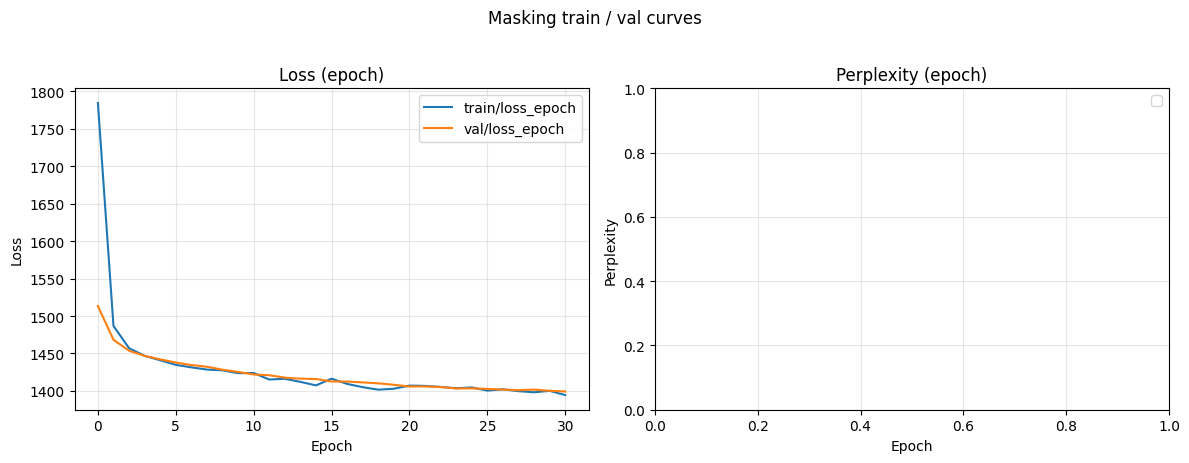

Saved curve: /home/stuke1/perturbgen/T_perturb/res/masking_split/masking_split_training_curves.png


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Prefer epoch-level masking metrics written by train-mask.
LOSS_TRAIN_CANDS = [
    "train/masking_loss_epoch",
    "train/loss_epoch",
    "train/loss",
]
LOSS_VAL_CANDS = ["val/loss_epoch", "val/loss"]
PPL_TRAIN_CANDS = ["train/perplexity_epoch", "train/perplexity"]
PPL_VAL_CANDS = ["val/perplexity_epoch", "val/perplexity"]


def find_metrics_csvs() -> list[Path]:
    roots = []
    for root in (WORKSPACE / "logs", LOG_ROOT):
        if root.exists():
            roots.append(root)
    cands = []
    for root in roots:
        cands.extend(root.glob("**/metrics.csv"))
    # Prefer cellgen masking runs; fall back to any metrics.csv.
    cellgen = [p for p in cands if "cellgen" in p.as_posix()]
    pool = cellgen or cands
    return sorted(pool, key=lambda p: p.stat().st_mtime)


def first_col(df: pd.DataFrame, names: list[str]) -> str | None:
    for name in names:
        if name in df.columns and df[name].notna().any():
            return name
    return None


def epoch_series(df: pd.DataFrame, col: str | None) -> pd.Series:
    if col is None or "epoch" not in df.columns:
        return pd.Series(dtype=float)
    tmp = df[["epoch", col]].dropna()
    if tmp.empty:
        return pd.Series(dtype=float)
    return tmp.groupby("epoch", as_index=True)[col].last().sort_index()


candidates = find_metrics_csvs()
if not candidates:
    raise FileNotFoundError("No metrics.csv under WORKSPACE/logs or LOG_ROOT")

metrics_path = candidates[-1]
df = pd.read_csv(metrics_path)

train_loss_col = first_col(df, LOSS_TRAIN_CANDS)
val_loss_col = first_col(df, LOSS_VAL_CANDS)
train_ppl_col = first_col(df, PPL_TRAIN_CANDS)
val_ppl_col = first_col(df, PPL_VAL_CANDS)

train_loss = epoch_series(df, train_loss_col)
val_loss = epoch_series(df, val_loss_col)
train_ppl = epoch_series(df, train_ppl_col)
val_ppl = epoch_series(df, val_ppl_col)

print("metrics.csv:", metrics_path)
print("epochs logged:", int(max(len(train_loss), len(val_loss), len(train_ppl), len(val_ppl))))
print(
    "columns used:",
    {
        "train_loss": train_loss_col,
        "val_loss": val_loss_col,
        "train_ppl": train_ppl_col,
        "val_ppl": val_ppl_col,
    },
)

summary_rows = []
for label, s in [
    (train_loss_col, train_loss),
    (val_loss_col, val_loss),
    (train_ppl_col, train_ppl),
    (val_ppl_col, val_ppl),
]:
    if label and not s.empty:
        summary_rows.append(
            {
                "metric": label,
                "last": float(s.iloc[-1]),
                "best": float(s.min()),
                "best_epoch": int(s.idxmin()),
            }
        )
summary = pd.DataFrame(summary_rows)
display(summary)

out_dir = Path(MASK_OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / "masking_split_training_curves.png"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
if not train_loss.empty:
    ax.plot(train_loss.index, train_loss.values, label=train_loss_col)
if not val_loss.empty:
    ax.plot(val_loss.index, val_loss.values, label=val_loss_col)
ax.set_title("Loss (epoch)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
if not train_ppl.empty:
    ax.plot(train_ppl.index, train_ppl.values, label=train_ppl_col)
if not val_ppl.empty:
    ax.plot(val_ppl.index, val_ppl.values, label=val_ppl_col)
ax.set_title("Perplexity (epoch)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Perplexity")
ax.grid(True, alpha=0.3)
ax.legend()

fig.suptitle("Masking train / val curves", y=1.02)
fig.tight_layout()
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved curve:", fig_path)

## 3.3. Train count decoder

Second-stage training on the **same** LPS tokenized data as masking:
`TOKENIZED = .../LPS_all_tps_2k`, frozen `--split_path`, `context_mode=True`.

Uses the masking checkpoint from §3.1 / §3.4:
`masking_split/...20260808_2325...epoch=49.ckpt`

Outputs go to `T_perturb/res/count_split/`. This checkpoint is what notebook 06 needs
(`use_count_decoder=True`).


In [ ]:
from pathlib import Path
import re

# Fallbacks if §3.1 config cell was not run in this kernel
if "MASK_OUTPUT_DIR" not in globals():
    MASK_OUTPUT_DIR = str(WORKSPACE / "T_perturb" / "res" / "masking_split")
if "SPLIT" not in globals():
    SPLIT = "True"
    TRAIN_PROP = 0.8
    TEST_PROP = 0.1
    SPLITTING_MODE = "stratified"
    SPLIT_OBS = "cell_type_harmonized"
if "SEED" not in globals():
    SEED = 0

COUNT_OUTPUT_DIR = str(WORKSPACE / "T_perturb" / "res" / "count_split")

# Same masking_split ckpt used for test metrics / embeddings (epoch=49)
CKPT_MASKING_PATH = str(
    Path(MASK_OUTPUT_DIR)
    / "checkpoints"
    / "20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt"
)

BATCH_SIZE = 64
EPOCHS = 40
COUNT_LR = 0.001
COUNT_WD = 0.001
CELLGEN_LR = 1e-4
CELLGEN_WD = 1e-4
MLM_PROB = 0.30
N_WORKERS = 4
NUM_LAYERS = 6
D_FF = 32
D_MODEL = 768
NUM_NODE = 1
LOSS_MODE = "zinb"  # mse | nb | zinb

COUNT_DROPOUT = 0.1
USE_POSITIONAL_ENCODING = "False"
LAYER_NORM = "True"
CONTEXT_MODE = "True"
POS_ENCODING_MODE = "time_pos_sin"
MASK_SCHEDULER = "pow"


def resolve_masking_ckpt(explicit: str, ckpt_dir: Path) -> Path:
    if explicit:
        path = Path(explicit)
        if not path.is_file():
            raise FileNotFoundError(f"CKPT_MASKING_PATH not found: {path}")
        return path
    candidates = list(ckpt_dir.glob("*.ckpt"))
    if not candidates:
        raise FileNotFoundError(f"No checkpoint found under {ckpt_dir}")

    def sort_key(path: Path):
        m = re.search(r"epoch=(\d+)", path.name)
        epoch = int(m.group(1)) if m else -1
        return (epoch, path.stat().st_mtime)

    return max(candidates, key=sort_key)


CKPT_MASKING_PATH = str(
    resolve_masking_ckpt(CKPT_MASKING_PATH, Path(MASK_OUTPUT_DIR) / "checkpoints")
)

print("COUNT_OUTPUT_DIR:", COUNT_OUTPUT_DIR)
print("CKPT_MASKING_PATH:", CKPT_MASKING_PATH)
print("Data (same as masking):", TOKENIZED)
print("SPLIT_PATH:", SPLIT_PATH)
print("CONTEXT_MODE:", CONTEXT_MODE, "| LOSS_MODE:", LOSS_MODE)


In [ ]:
if not CKPT_MASKING_PATH:
    raise ValueError(
        "Set CKPT_MASKING_PATH to your trained masking checkpoint before running count decoder."
    )

count_cmd = [
    "python",
    "-m",
    "perturbgen",
    "train-decoder",
    "--train_mode", "count",
    "--split", SPLIT,
    "--split_path", SPLIT_PATH,
    "--train_prop", str(TRAIN_PROP),
    "--test_prop", str(TEST_PROP),
    "--splitting_mode", SPLITTING_MODE,
    "--split_obs", SPLIT_OBS,
    "--output_dir", COUNT_OUTPUT_DIR,
    "--ckpt_masking_path", str(CKPT_MASKING_PATH),
    "--src_dataset", SRC_DATASET,
    "--tgt_dataset_folder", TGT_DATASET_FOLDER,
    "--src_adata", SRC_ADATA,
    "--tgt_adata_folder", TGT_ADATA_FOLDER,
    "--mapping_dict_path", MAPPING_DICT_PATH,
    "--batch_size", str(BATCH_SIZE),
    "--epochs", str(EPOCHS),
    "--count_lr", str(COUNT_LR),
    "--cellgen_lr", str(CELLGEN_LR),
    "--cellgen_wd", str(CELLGEN_WD),
    "--count_wd", str(COUNT_WD),
    "--mlm_prob", str(MLM_PROB),
    "--n_workers", str(N_WORKERS),
    "--num_layers", str(NUM_LAYERS),
    "--d_ff", str(D_FF),
    "--loss_mode", LOSS_MODE,
    "--pred_tps", *PRED_TPS,
    "--var_list", *VAR_LIST,
    "--encoder", "scmaskgit",
    "--count_dropout", str(COUNT_DROPOUT),
    "--use_positional_encoding", USE_POSITIONAL_ENCODING,
    "--layer_norm", LAYER_NORM,
    "--context_mode", CONTEXT_MODE,
    "--encoder_path", ENCODER_PATH,
    "--pos_encoding_mode", POS_ENCODING_MODE,
    "--mask_scheduler", MASK_SCHEDULER,
    "--num_node", str(NUM_NODE),
    "--d_model", str(D_MODEL),
    "--ckpt_every_n_epochs", "5",
    "--seed", str(SEED),
    "--wandb_mode", "disabled",
]

print(" ".join(count_cmd))


### Launch count-decoder training

Defaults: **4 GPUs** (`CUDA_VISIBLE_DEVICES=0,1,2,7`), `batch_size=64`, `epochs=40`, `--wandb_mode disabled`.
AnnData is excluded from Lightning hparams (`CountDecoderTrainer.save_hyperparameters(ignore=['tgt_adata'])`).

After it finishes, point notebook 06 / `perturbation.yaml` `ckpt_masking_path` at the new
count-decoder checkpoint under `COUNT_OUTPUT_DIR/checkpoints/`.

**Note:** notebook 06’s default YAML still points at `lps_90min_perturb` (90m-as-source).
For this LPS_all_tps_2k count decoder you will need matching data paths in that YAML later.

After training: §3.5 plots train/val curves; §3.6 runs held-out count test metrics.


In [ ]:
print("Launching clean count-decoder run on GPUs", os.environ["CUDA_VISIBLE_DEVICES"])
count_log_file = run_and_stream(count_cmd, job_name="count_train_split")
print("count_log_file:", count_log_file)

## 3.4. Test masking metrics (no embeddings)

Held-out **test** metrics only: `test/loss` and `test/perplexity` (`--return_embeddings False`).

Default checkpoint is the new **50-epoch** run:
`masking_split/...20260808_2325...epoch=49.ckpt`
with the same frozen `--split_path` as training.

`QUICK_TEST=True` only shrinks `pred_tps` / batch size — it does **not** change the test split.

In [11]:
import re
from pathlib import Path

# --- metrics-only test toggles ---
METRICS_ONLY = True  # embeddings off -> report test/loss + test/perplexity
QUICK_TEST = False   # True: pred_tps=[1] + larger batch (split unchanged)

# New 50-epoch frozen-split run (set "" to auto-pick highest-epoch ckpt under MASK_OUTPUT_DIR)
CKPT_MASKING_TEST = str(
    Path(MASK_OUTPUT_DIR)
    / "checkpoints"
    / "20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt"
)

TEST_OUTPUT_DIR = str(WORKSPACE / "T_perturb" / "res" / "masking_split_test_metrics_50ep")
TEST_BATCH_SIZE = 128 if QUICK_TEST else 64
TEST_N_WORKERS = 0
TEST_WANDB_MODE = "disabled"

pred_tps_test = ["1"] if QUICK_TEST else PRED_TPS
return_embeddings_test = "False" if METRICS_ONLY else "True"


def resolve_masking_ckpt(explicit: str, ckpt_dir: Path) -> Path:
    if explicit:
        path = Path(explicit)
        if not path.is_file():
            raise FileNotFoundError(f"CKPT_MASKING_TEST not found: {path}")
        return path
    candidates = list(ckpt_dir.glob("*.ckpt"))
    if not candidates:
        raise FileNotFoundError(f"No checkpoint found under {ckpt_dir}")

    def sort_key(path: Path):
        m = re.search(r"epoch=(\d+)", path.name)
        epoch = int(m.group(1)) if m else -1
        return (epoch, path.stat().st_mtime)

    return max(candidates, key=sort_key)


ckpt_path = resolve_masking_ckpt(CKPT_MASKING_TEST, Path(MASK_OUTPUT_DIR) / "checkpoints")
CKPT_MASKING_TEST = str(ckpt_path)

print("Using checkpoint:", CKPT_MASKING_TEST)
print("SPLIT_PATH:", SPLIT_PATH)
print("TEST_OUTPUT_DIR:", TEST_OUTPUT_DIR)
print("METRICS_ONLY:", METRICS_ONLY)
print("QUICK_TEST:", QUICK_TEST)
print("pred_tps_test:", pred_tps_test)
print("return_embeddings_test:", return_embeddings_test)

# split_path alone selects indices; train_prop / splitting_mode not needed
test_cmd = [
    "python", "-m", "perturbgen", "extract-embedding",
    "--test_mode", "masking",
    "--split", "True",
    "--split_path", SPLIT_PATH,
    "--ckpt_masking_path", CKPT_MASKING_TEST,
    "--generate", "False",
    "--return_embeddings", return_embeddings_test,
    "--return_gene_embs", "False",
    "--return_attn", "False",
    "--output_dir", TEST_OUTPUT_DIR,
    "--src_dataset", SRC_DATASET,
    "--tgt_dataset_folder", TGT_DATASET_FOLDER,
    "--src_adata", SRC_ADATA,
    "--tgt_adata_folder", TGT_ADATA_FOLDER,
    "--mapping_dict_path", MAPPING_DICT_PATH,
    "--pred_tps", *pred_tps_test,
    "--encoder", "scmaskgit",
    "--encoder_path", ENCODER_PATH,
    "--batch_size", str(TEST_BATCH_SIZE),
    "--n_workers", str(TEST_N_WORKERS),
    "--num_layers", str(NUM_LAYERS),
    "--d_ff", str(D_FF),
    "--d_model", str(D_MODEL),
    "--mask_scheduler", MASK_SCHEDULER,
    "--var_list", *VAR_LIST,
    "--wandb_mode", TEST_WANDB_MODE,
]

# headless + cache dirs (single-GPU test)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["MPLBACKEND"] = "Agg"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["HWLOC_COMPONENTS"] = "-gl"
os.environ["HWLOC_GL_LINUX_NVIDIA_DISABLE"] = "1"
os.environ["WANDB_MODE"] = TEST_WANDB_MODE
os.environ.pop("DISPLAY", None)
os.environ.pop("WAYLAND_DISPLAY", None)

print("Launching metrics-only masking test on GPU", os.environ["CUDA_VISIBLE_DEVICES"])
print(" ".join(test_cmd))
test_log_file = run_and_stream(test_cmd, job_name="masking_test_metrics_50ep")
print("test_log_file:", test_log_file)
print("Look in notebook output for: test/loss  and  test/perplexity")


Using checkpoint: /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
SPLIT_PATH: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl
TEST_OUTPUT_DIR: /home/stuke1/perturbgen/T_perturb/res/masking_split_test_metrics_50ep
METRICS_ONLY: True
QUICK_TEST: False
pred_tps_test: ['1', '2', '3']
return_embeddings_test: False
Launching metrics-only masking test on GPU 0
python -m perturbgen extract-embedding --test_mode masking --split True --split_path /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl --ckpt_masking_path /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt --generate False --return_embeddings 

## 3.5. Count decoder: train / val curves

Run after §3.3. Loads Lightning `metrics.csv` from the count run
(`logs/20260809_1447_cellgen` by default; override `COUNT_METRICS_CSV` if needed).

Plots epoch-level **loss**, **MSE**, and **EMD** (train vs val) and saves the figure under
`COUNT_OUTPUT_DIR`.


metrics.csv: /home/stuke1/perturbgen/logs/20260809_1447_cellgen/version_0/metrics.csv
        train/loss     val/loss  train/mse   val/mse  train/emd   val/emd
epoch                                                                    
21.0   1406.714722  1405.958618   3.043664  2.787694   0.121533  0.113261
22.0   1405.349976  1405.185913   3.026972  2.812096   0.120878  0.113945
23.0   1403.580078  1403.254272   3.029588  2.751170   0.120493  0.113880
24.0   1404.615479  1403.453247   2.991168  2.900396   0.120750  0.114412
25.0   1400.428711  1402.654053   3.038002  2.811046   0.120199  0.115932
26.0   1402.160645  1401.828125   2.993065  2.885020   0.119502  0.116174
27.0   1399.662231  1400.942383   3.067215  2.750133   0.119511  0.112757
28.0   1398.188232  1401.795410   2.983037  2.794939   0.119294  0.114972
29.0   1400.097656  1400.118408   3.023791  2.739377   0.118732  0.115542
30.0   1394.399536  1399.270386   2.917984  2.725098   0.118806  0.114179

Best val/mse: epoch 30 = 

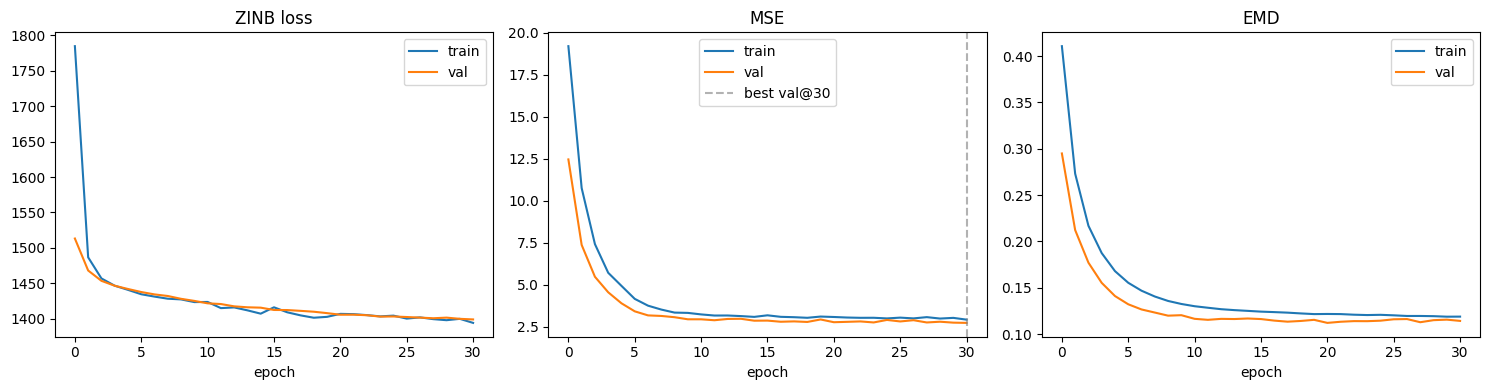

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

if "COUNT_OUTPUT_DIR" not in globals():
    COUNT_OUTPUT_DIR = str(WORKSPACE / "T_perturb" / "res" / "count_split")

# Default: the completed 8-GPU batch_256 run (epoch 0–30)
COUNT_METRICS_CSV = WORKSPACE / "logs" / "20260809_1447_cellgen" / "version_0" / "metrics.csv"

# Fallback: newest cellgen metrics.csv under logs/
if not COUNT_METRICS_CSV.is_file():
    cands = sorted(
        (WORKSPACE / "logs").glob("**/metrics.csv"),
        key=lambda q: q.stat().st_mtime,
    )
    cellgen = [q for q in cands if "cellgen" in q.as_posix()]
    COUNT_METRICS_CSV = (cellgen or cands)[-1]

df_count = pd.read_csv(COUNT_METRICS_CSV)


def epoch_series(frame: pd.DataFrame, col: str) -> pd.Series:
    if col not in frame.columns or "epoch" not in frame.columns:
        return pd.Series(dtype=float)
    tmp = frame[["epoch", col]].dropna()
    if tmp.empty:
        return pd.Series(dtype=float)
    return tmp.groupby("epoch", as_index=True)[col].last().sort_index()


train_loss = epoch_series(df_count, "train/loss_epoch")
val_loss = epoch_series(df_count, "val/loss_epoch")
train_mse = epoch_series(df_count, "train/mse_epoch")
val_mse = epoch_series(df_count, "val/mse_epoch")
train_emd = epoch_series(df_count, "train/emd")
val_emd = epoch_series(df_count, "val/emd")

summary = pd.DataFrame(
    {
        "train/loss": train_loss,
        "val/loss": val_loss,
        "train/mse": train_mse,
        "val/mse": val_mse,
        "train/emd": train_emd,
        "val/emd": val_emd,
    }
)
print("metrics.csv:", COUNT_METRICS_CSV)
print(summary.tail(10))
if not val_mse.empty:
    print(
        f"\nBest val/mse: epoch {int(val_mse.idxmin())} = {float(val_mse.min()):.4f}"
    )
if not val_loss.empty:
    print(
        f"Best val/loss: epoch {int(val_loss.idxmin())} = {float(val_loss.min()):.4f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_loss.index, train_loss.values, label="train")
axes[0].plot(val_loss.index, val_loss.values, label="val")
axes[0].set_title("ZINB loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(train_mse.index, train_mse.values, label="train")
axes[1].plot(val_mse.index, val_mse.values, label="val")
if not val_mse.empty:
    axes[1].axvline(
        val_mse.idxmin(),
        color="gray",
        ls="--",
        alpha=0.6,
        label=f"best val@{int(val_mse.idxmin())}",
    )
axes[1].set_title("MSE")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(train_emd.index, train_emd.values, label="train")
axes[2].plot(val_emd.index, val_emd.values, label="val")
axes[2].set_title("EMD")
axes[2].set_xlabel("epoch")
axes[2].legend()

fig.tight_layout()
out_png = Path(COUNT_OUTPUT_DIR) / "count_train_val_curves.png"
Path(COUNT_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print("saved:", out_png)
plt.show()


## 3.6. Test count metrics (held-out split)

Held-out **test** for the count decoder (`--generate False`):

- Lightning logs **`test/loss_epoch`** (ZINB NLL). Step rows leave the epoch column as NaN — that is normal CSVLogger formatting, not a failed run.
- Additional gene-space summary is written to `COUNT_TEST_OUTPUT_DIR/test_metrics.csv` (lin-reg / RMSE / Pearson).

Uses:
- frozen masking backbone (epoch=49)
- count checkpoint with best `val/mse` (default **epoch=29**)
- same frozen `--split_path` and `context_mode=True` as training

Single GPU is enough for this metrics-only test.


In [9]:
import os
import re
from pathlib import Path

if "COUNT_OUTPUT_DIR" not in globals():
    COUNT_OUTPUT_DIR = str(WORKSPACE / "T_perturb" / "res" / "count_split")
if "MASK_OUTPUT_DIR" not in globals():
    MASK_OUTPUT_DIR = str(WORKSPACE / "T_perturb" / "res" / "masking_split")
if "SEED" not in globals():
    SEED = 0

# Masking backbone (same as count training)
CKPT_MASKING_FOR_COUNT_TEST = str(
    Path(MASK_OUTPUT_DIR)
    / "checkpoints"
    / "20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt"
)

# Best count ckpt by val/mse from §3.5 (epoch=29). Set "" to auto-pick highest epoch.
CKPT_COUNT_TEST = str(
    Path(COUNT_OUTPUT_DIR)
    / "checkpoints"
    / "20260809_1447_cellgen_train_count_lr_0.001_wd_0.001_batch_256_drop_0.1_zinb_tp_1-2-3_s_0_pos_time_pos_sin_m_pow-epoch=29.ckpt"
)

COUNT_TEST_OUTPUT_DIR = str(
    WORKSPACE / "T_perturb" / "res" / "count_split_test_metrics"
)
COUNT_TEST_BATCH_SIZE = 64
COUNT_TEST_N_WORKERS = 4
COUNT_TEST_WANDB_MODE = "disabled"


def resolve_count_ckpt(explicit: str, ckpt_dir: Path) -> Path:
    if explicit:
        path = Path(explicit)
        if not path.is_file():
            raise FileNotFoundError(f"CKPT_COUNT_TEST not found: {path}")
        return path
    candidates = list(ckpt_dir.glob("*.ckpt"))
    if not candidates:
        raise FileNotFoundError(f"No count checkpoint under {ckpt_dir}")

    def sort_key(path: Path):
        m = re.search(r"epoch=(\d+)", path.name)
        epoch = int(m.group(1)) if m else -1
        return (epoch, path.stat().st_mtime)

    return max(candidates, key=sort_key)


CKPT_COUNT_TEST = str(
    resolve_count_ckpt(CKPT_COUNT_TEST, Path(COUNT_OUTPUT_DIR) / "checkpoints")
)
assert Path(CKPT_MASKING_FOR_COUNT_TEST).is_file(), CKPT_MASKING_FOR_COUNT_TEST

count_test_cmd = [
    "python", "-m", "perturbgen", "extract-embedding",
    "--test_mode", "count",
    "--split", "True",
    "--split_path", SPLIT_PATH,
    "--ckpt_masking_path", CKPT_MASKING_FOR_COUNT_TEST,
    "--ckpt_count_path", CKPT_COUNT_TEST,
    "--generate", "False",
    "--return_embeddings", "False",
    "--return_gene_embs", "False",
    "--return_attn", "False",
    "--output_dir", COUNT_TEST_OUTPUT_DIR,
    "--src_dataset", SRC_DATASET,
    "--tgt_dataset_folder", TGT_DATASET_FOLDER,
    "--src_adata", SRC_ADATA,
    "--tgt_adata_folder", TGT_ADATA_FOLDER,
    "--mapping_dict_path", MAPPING_DICT_PATH,
    "--batch_size", str(COUNT_TEST_BATCH_SIZE),
    "--n_workers", str(COUNT_TEST_N_WORKERS),
    "--num_layers", "6",
    "--d_ff", "32",
    "--d_model", "768",
    "--loss_mode", "zinb",
    "--pred_tps", *PRED_TPS,
    "--var_list", *VAR_LIST,
    "--encoder", "scmaskgit",
    "--encoder_path", ENCODER_PATH,
    "--context_mode", "True",
    "--pos_encoding_mode", "time_pos_sin",
    "--mask_scheduler", "pow",
    "--count_dropout", "0.1",
    "--use_positional_encoding", "False",
    "--layer_norm", "True",
    "--seed", str(SEED),
    "--wandb_mode", COUNT_TEST_WANDB_MODE,
]

print("CKPT_MASKING:", CKPT_MASKING_FOR_COUNT_TEST)
print("CKPT_COUNT:", CKPT_COUNT_TEST)
print("SPLIT_PATH:", SPLIT_PATH)
print("COUNT_TEST_OUTPUT_DIR:", COUNT_TEST_OUTPUT_DIR)
print(" ".join(count_test_cmd))


CKPT_MASKING: /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
CKPT_COUNT: /home/stuke1/perturbgen/T_perturb/res/count_split/checkpoints/20260809_1447_cellgen_train_count_lr_0.001_wd_0.001_batch_256_drop_0.1_zinb_tp_1-2-3_s_0_pos_time_pos_sin_m_pow-epoch=29.ckpt
SPLIT_PATH: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl
COUNT_TEST_OUTPUT_DIR: /home/stuke1/perturbgen/T_perturb/res/count_split_test_metrics
python -m perturbgen extract-embedding --test_mode count --split True --split_path /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl --ckpt_masking_path /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-e

In [10]:
import pandas as pd
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["MPLBACKEND"] = "Agg"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["HWLOC_COMPONENTS"] = "-gl"
os.environ["HWLOC_GL_LINUX_NVIDIA_DISABLE"] = "1"
os.environ["WANDB_MODE"] = COUNT_TEST_WANDB_MODE
os.environ.pop("DISPLAY", None)
os.environ.pop("WAYLAND_DISPLAY", None)

print("Launching count test on GPU", os.environ["CUDA_VISIBLE_DEVICES"])
count_test_log = run_and_stream(count_test_cmd, job_name="count_test_metrics")
print("count_test_log:", count_test_log)

# Lightning CSV: step rows have test/*_step filled and test/*_epoch = NaN;
# the final epoch row has test/*_epoch filled. Prefer epoch columns only.
cands = sorted(
    (WORKSPACE / "logs").glob("**/metrics.csv"),
    key=lambda q: q.stat().st_mtime,
)
metrics_path = cands[-1]
tdf = pd.read_csv(metrics_path)
epoch_cols = [c for c in tdf.columns if str(c).startswith("test/") and str(c).endswith("_epoch")]
step_cols = [c for c in tdf.columns if str(c).startswith("test/") and str(c).endswith("_step")]

print("\nLightning metrics.csv:", metrics_path)
if epoch_cols:
    epoch_summary = tdf[epoch_cols].dropna(how="all")
    print("test epoch metrics:")
    print(epoch_summary.tail(5).to_string(index=False))
    print("\nfinal test/loss_epoch:", float(epoch_summary[epoch_cols[0]].dropna().iloc[-1]))
elif step_cols:
    # fallback if only step metrics were logged
    print("No *_epoch columns; mean of step metrics:")
    print(tdf[step_cols].dropna(how="all").mean(numeric_only=True))
else:
    print("No test/* columns — check count_test_log / notebook stdout.")

# Gene-space summary written by CountDecoderTrainer.on_test_epoch_end
extra = Path(COUNT_TEST_OUTPUT_DIR) / "test_metrics.csv"
if extra.is_file():
    print("\nCOUNT_TEST_OUTPUT_DIR/test_metrics.csv:")
    print(pd.read_csv(extra).to_string(index=False))
else:
    print("\nNo test_metrics.csv under", COUNT_TEST_OUTPUT_DIR)


Launching count test on GPU 0

$ python -m perturbgen extract-embedding --test_mode count --split True --split_path /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl --ckpt_masking_path /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt --ckpt_count_path /home/stuke1/perturbgen/T_perturb/res/count_split/checkpoints/20260809_1447_cellgen_train_count_lr_0.001_wd_0.001_batch_256_drop_0.1_zinb_tp_1-2-3_s_0_pos_time_pos_sin_m_pow-epoch=29.ckpt --generate False --return_embeddings False --return_gene_embs False --return_attn False --output_dir /home/stuke1/perturbgen/T_perturb/res/count_split_test_metrics --src_dataset /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_src/normal.dataset --tgt_dataset_folder /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps